# Практическая работа №3

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyexpat import features
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import numpy as np
import optuna

In [54]:
data = pd.read_csv("data_sets/practice3.csv")

In [55]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959,3.080,8.381,9.781,3.763,-0.783,-1.257,-1.723,0.650,0.860,0.887,0.958,0.055,unstable
1,9.304,4.903,3.048,1.369,5.068,-1.940,-1.873,-1.255,0.413,0.862,0.562,0.782,-0.006,stable
2,8.972,8.848,3.046,1.215,3.405,-1.207,-1.277,-0.920,0.163,0.767,0.839,0.110,0.003,unstable
3,0.716,7.670,4.487,2.341,3.964,-1.027,-1.939,-0.997,0.446,0.977,0.929,0.363,0.029,unstable
4,3.134,7.609,4.944,9.858,3.526,-1.126,-1.846,-0.554,0.797,0.455,0.657,0.821,0.050,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930,9.488,2.377,6.188,3.343,-0.658,-1.449,-1.236,0.602,0.780,0.814,0.608,0.024,unstable
9996,3.392,1.275,2.955,6.895,4.350,-1.664,-0.952,-1.733,0.502,0.567,0.286,0.366,-0.026,stable
9997,2.364,2.842,8.776,1.009,4.300,-1.381,-0.944,-1.975,0.488,0.987,0.149,0.146,-0.032,stable
9998,9.632,3.994,2.757,7.821,2.515,-0.966,-0.650,-0.899,0.365,0.588,0.889,0.818,0.038,unstable


In [56]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


Информация о датасете:

* tau - время реакции участка

* `tau1` - значение для производителя электроэнергии

* `tau2`, `tau3`, `tau4` - значения для потребителей

* p - номинальная мощность

* `p1` - абсолютное значение суммы мощностей потребителей

* `p2`, `p3`, `p3` - мощности потребителей

* g - коэффициент, пропорциональный ценовой эластичности

* `g1` - для производителя

* `g2`, `g3`, `g4` - для потребителей

* `stab` - максимальная действительная часть корня характеристического уравнения

* `stabf` - метка стабильности системы

### Статистический анализ

In [57]:
data.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5.250,5.250,5.250,5.250,3.750,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.016
std,2.743,2.743,2.743,2.743,0.752,0.433,0.433,0.433,0.274,0.274,0.274,0.274,0.037
min,0.501,0.500,0.501,0.500,1.583,-2.000,-2.000,-2.000,0.050,0.050,0.050,0.050,-0.081
25%,2.875,2.875,2.876,2.875,3.218,-1.625,-1.625,-1.625,0.288,0.288,0.288,0.287,-0.016
50%,5.250,5.250,5.250,5.250,3.751,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.017
75%,7.625,7.625,7.625,7.625,4.282,-0.875,-0.875,-0.875,0.762,0.762,0.762,0.762,0.045
max,9.999,10.000,9.999,9.999,5.864,-0.500,-0.500,-0.500,1.000,1.000,1.000,1.000,0.109


<Figure size 640x480 with 0 Axes>

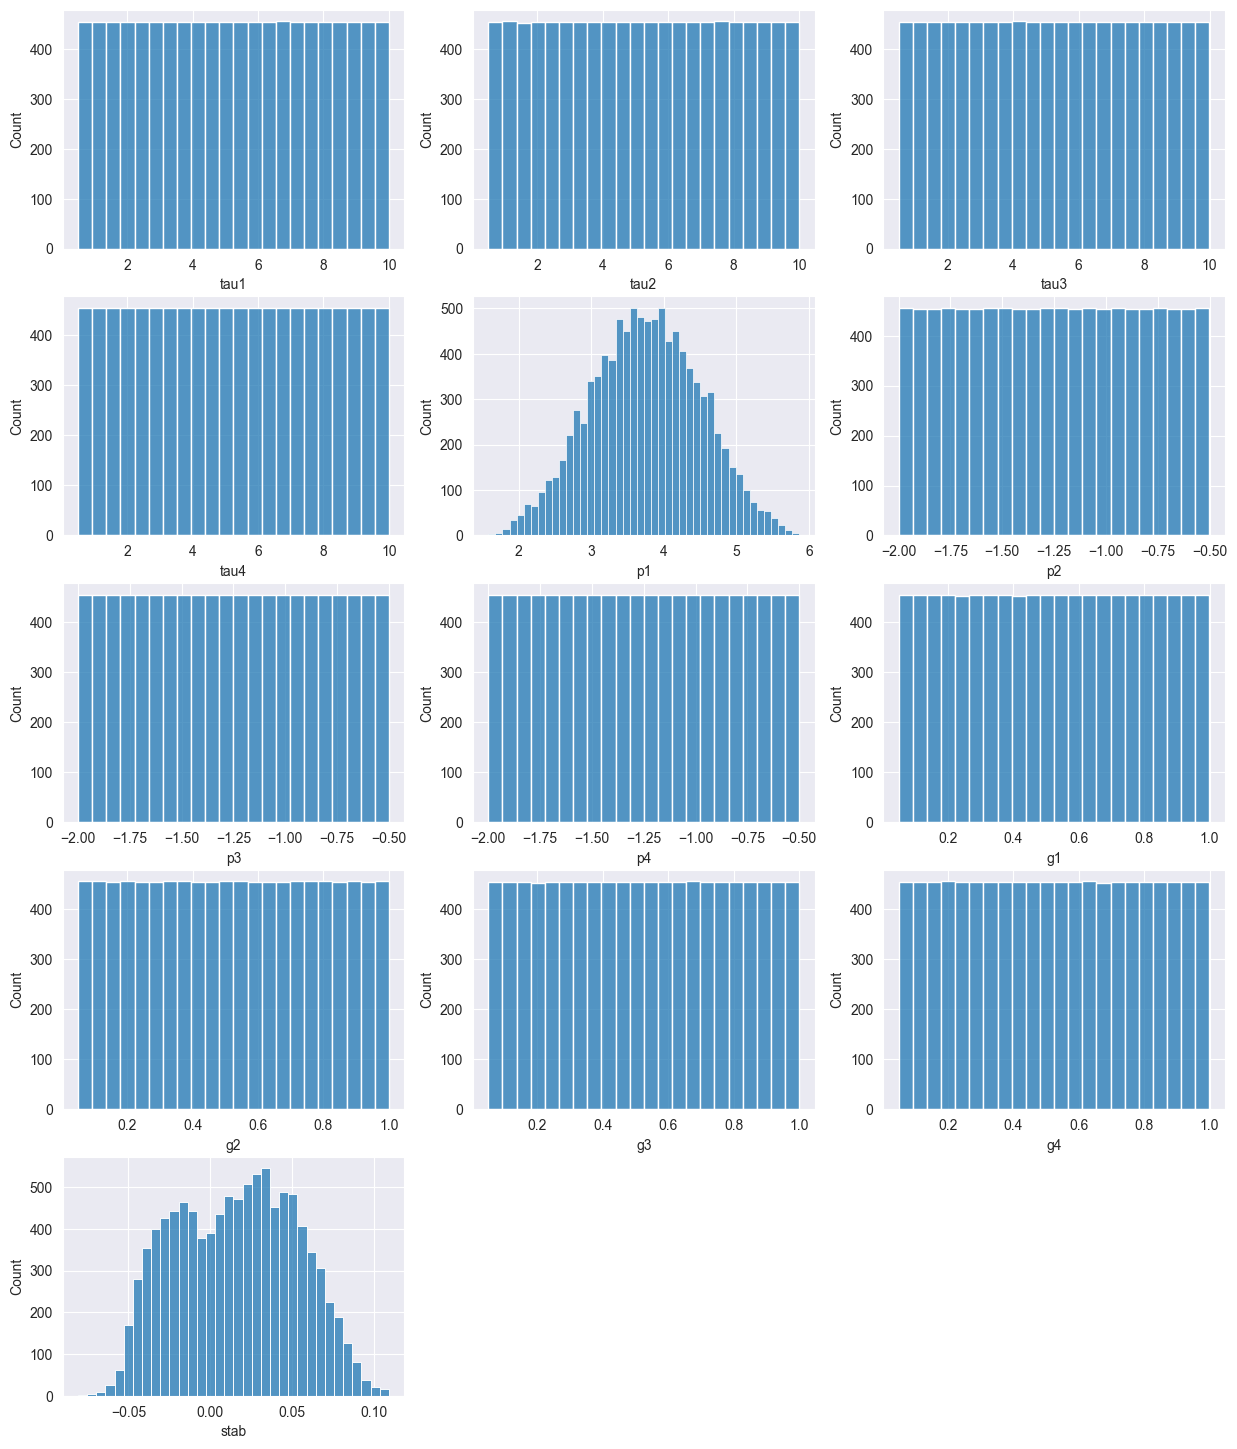

In [58]:
numeric_columns = data.select_dtypes(include=['number']).columns
plt.subplots_adjust(wspace=0.9, hspace=0.9)
fig, ax = plt.subplots(5, 3, figsize=(15, 18))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=data[column], ax=ax)


axes[-1].set_visible(False)
axes[-2].set_visible(False)

Время реакции участка для производителя и потребителей (`tau1`, `tau2`, `tau3` и `tau4`) распределено равномерно и лежит в диапазоне от 0 до 10.

Мощности потребителей (`p2`, `p3`, `p4`) распределены равномерно и лежат в диапазоне от -2 до -0.5.

Ценовая эластичность (`g1`, `g2`, `g3`, `g4`) для производителя и потребителей распределена равномерно и лежит в диапазоне от 0 до 1.

Мощность производителя (`p1`) имеет распределение, очень близкое к нормальному. Лежит в диапазоне от 1.6 до 5.9.

Так как значение медианы для `stab `равно 0.017, то можно сказать, что более, чем в половине зафиксированных случаев, система является нестабильной.

### Анализ выбросов

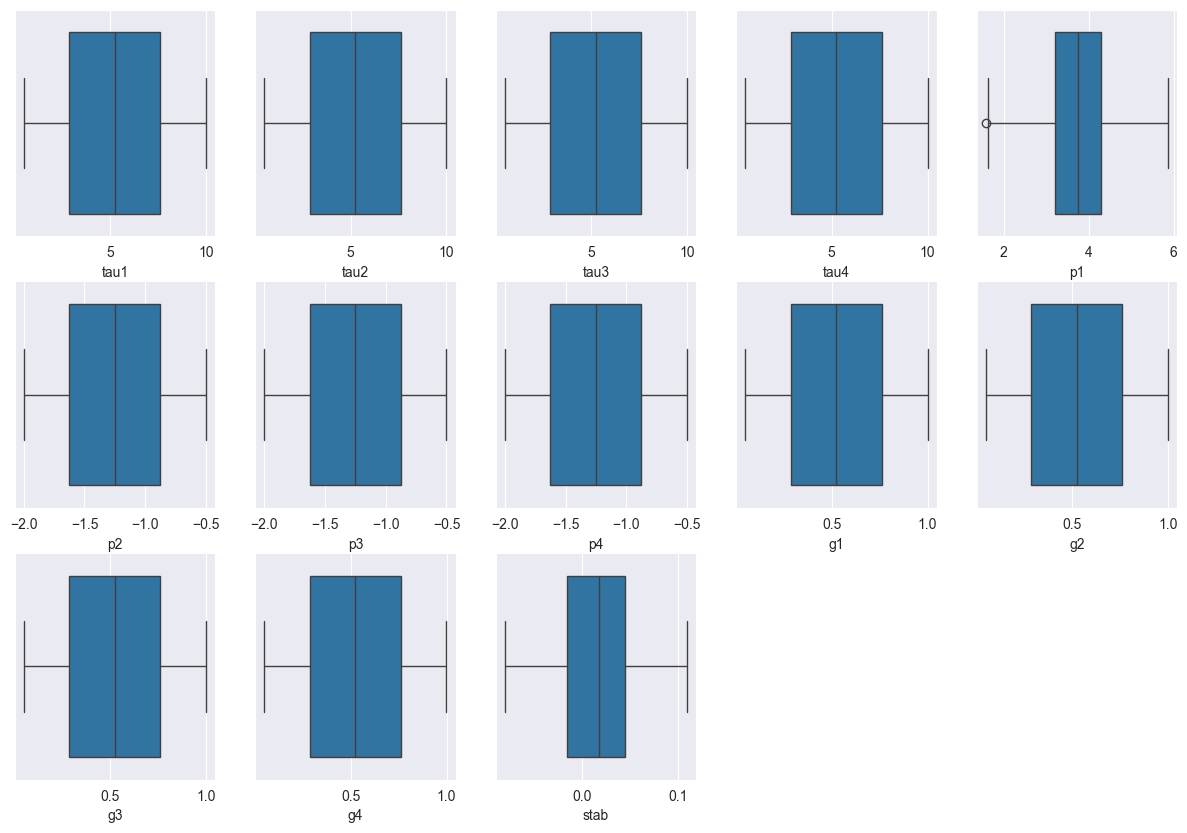

In [59]:
numeric_columns = data.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x = data[column], ax=ax)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

In [60]:
iqr = data["p1"].quantile(0.75) - data["p1"].quantile(0.25)

data[data["p1"] <= 1.5 * iqr]

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6273,6.698,7.861,9.333,2.434,1.583,-0.504,-0.572,-0.507,0.642,0.868,0.494,0.411,0.057,unstable


Данное значение является аномальным с очень низким уровнем использования мощности, его не стоит удалять.

### Корреляционный анализ

In [61]:
vif_data = pd.DataFrame()

vif_data["VIF"] = [variance_inflation_factor(data[numeric_columns].values, i) for i in range(data[numeric_columns].shape[1])]

vif_data["Features"] = data[numeric_columns].columns

vif_data

C:\Users\stwz13\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Features
0,4.565,tau1
1,4.526,tau2
2,4.546,tau3
3,4.487,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.511,g1
9,4.579,g2


Заметим, что для `p1`, `p2`, `p3` и `p4` коэффициент VIF принимает значение inf. Это объясняется наличием мультиколлинеарности: `p1` равно абсолютному значению суммы `p2`, `p3` и `p4`.

Переменная `stab` имеет наименьший коэффициент VIF, равный 1.86. Значит, значения данной переменной практически не подвержены мультиколлинеарности

Прочие переменные не подвержены сильной мультиколлинеарности: значения коэффициента VIF для них лежат в интервале от 4.5 до 5.5.

<Axes: >

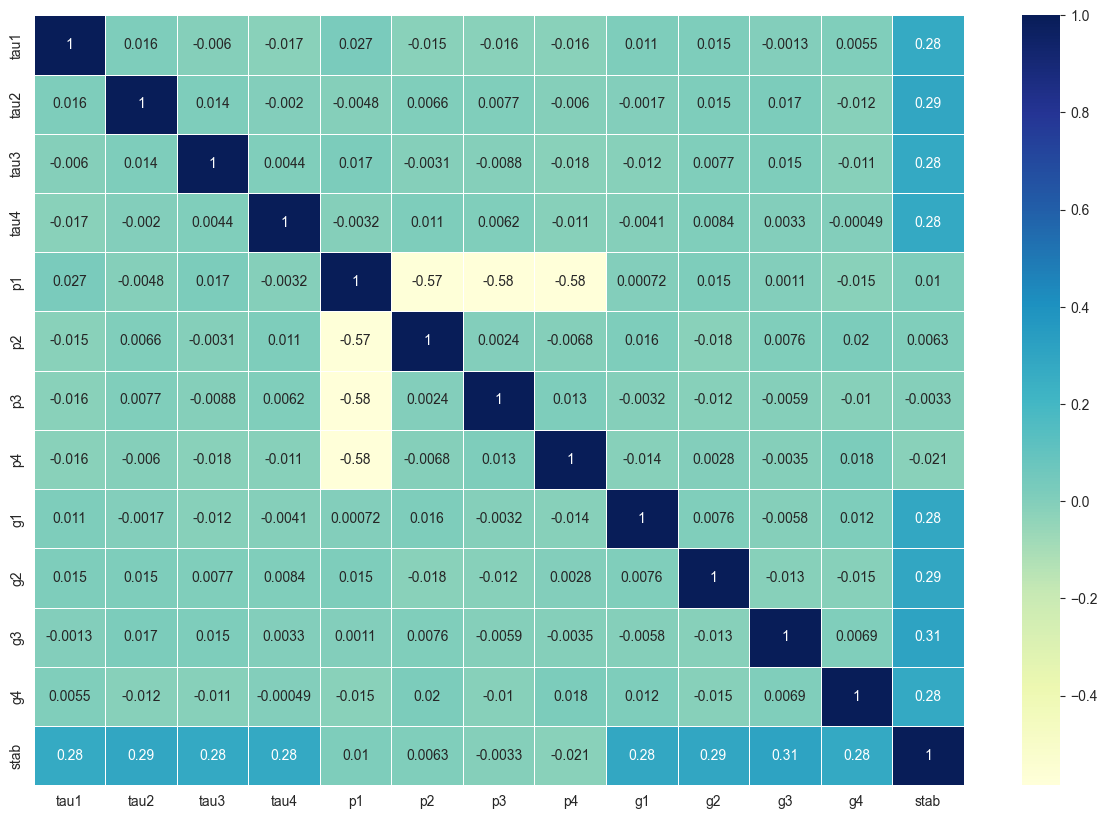

In [62]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap="YlGnBu", linewidths=.5 )

Средней корреляцией обладает переменная `p1` с признаками `p2`, `p3`, `p4`. Это объясняется тем, что между ними существует прямая линейная зависимость.

Переменная `stab ` обладает слабой корреляцией с `tau1`, `tau2`, `tau3`, `tau4` и `g1`, `g2`, `g3`, `g4`. Значит, устойчивость системы в большей степени определяется временем реакции и ценовой эластичностью, чем потребляемой мощностью.

### Кодирование категориальных признаков

In [63]:
data["stabf"] = data["stabf"].map({"stable": 1, "unstable": 0})

### Масштабирование

In [64]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numeric_columns])

scaled_df = pd.DataFrame(scaled_data, index=data[numeric_columns].index, columns=data[numeric_columns].columns)
scaled_df = pd.concat([scaled_df, data["stabf"]], axis=1)

## Обучение модели регрессии

Прежде, чем приступить к обучению моделей, сделаем несколько вспомогательных инструментов для избежания дублирования кода.

Функция `get_metrics` возвращает список из рассчитанных метрических показателей для предсказанных и истинных значений.

In [65]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]
    results = [
        round(r2_score(y_test, y_predicted), 2),
        round(mean_squared_error(y_test, y_predicted), 4),
        round(root_mean_squared_error(y_test, y_predicted), 4),
        round(mean_absolute_error(y_test, y_predicted), 4),
        round(mean_absolute_percentage_error(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

Функция `input_into_the_tables` будет использоваться для вставки полученных значений метрик в результирующую таблицу со всеми моделями.

In [66]:
def input_metrics_into_the_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          train_and_test_comparing):
    sk_learn_test_metrics = get_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = get_metrics(y_train, predict_on_train_y)

    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

Функция `train_models_with_reg` обучает модели с L1, L2 и ElasticNet регуляризациями с использованием GridSearch, RandomSearch, Optuna и возвращает полученные модели в словаре.

In [67]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def train_models_with_reg(X_train, y_train, X_test, y_test):

    result={}
    alpha_range = np.logspace(-3, 2).tolist()

    types_of_reg = {
        "L1": {
            "reg": Lasso,
            "param_grid": {"alpha": alpha_range}
        },
        "L2":
            {
                "reg": Ridge,
                "param_grid": {"alpha": alpha_range}
            },
        "EN":
            {
                "reg": ElasticNet,
                "param_grid":{
                        "alpha": alpha_range,
                        "l1_ratio": np.arange(0.1, 1, 0.3).tolist()
                }

            }

    }

    for name, reg_info in types_of_reg.items():

        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            params = {"alpha": trial.suggest_float('alpha', 1e-3, 1e2, log=True)}
            if name == "EN":
                params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.1, 1)

            model = type_of_reg(**params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            return mse

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result


Ниже происходит создание датафрейма для хранения метрик.

In [68]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)

train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [69]:
X = scaled_df.drop("stab", axis=1)
y = scaled_df["stab"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, random_state=13, test_size=0.2)

Для начала обучим модель множественной регрессии без регуляризации.

### Множественная регрессия без регуляризации

In [70]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

simple_model.coef_

array([ 1.43677936e-01,  1.53279556e-01,  1.52705968e-01,  1.50725576e-01,
        1.83224341e-03, -2.66862035e-03, -1.31621955e-04, -3.82273622e-04,
        1.73497526e-01,  1.73622285e-01,  1.84468149e-01,  1.71695472e-01,
       -1.11991569e+00])

In [71]:
simple_regression_model_train_predict = simple_model.predict(X_train)
simple_regression_model_test_predict = simple_model.predict(X_val_test)

input_metrics_into_the_table(
    "Linear regression without regularization",
    simple_regression_model_train_predict, y_train,
    simple_regression_model_test_predict, y_val_test,
    train_and_test_comparing
)

train_and_test_comparing.loc["Linear regression without regularization"]

Train Data  R2     0.820
            MSE    0.185
            RMSE   0.430
            MAE    0.343
            MAPE   1.970
Test Data   R2     0.810
            MSE    0.185
            RMSE   0.431
            MAE    0.343
            MAPE   3.029
Name: Linear regression without regularization, dtype: float64

Модель работает практически одинаково хорошо на тренировочной и тестовой выборках. Попробуем применить регуляризацию для модели.

<Axes: ylabel='stab'>

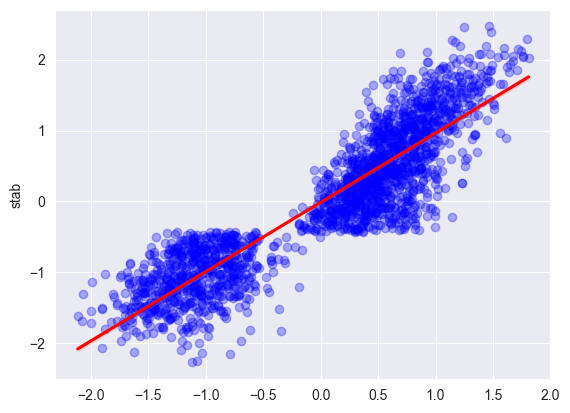

In [72]:
sns.regplot(x = simple_regression_model_test_predict, y=y_val_test, line_kws={"color": "r"}, scatter_kws={"color": "b", "alpha": 0.3})

NameError: name 'y_test' is not defined

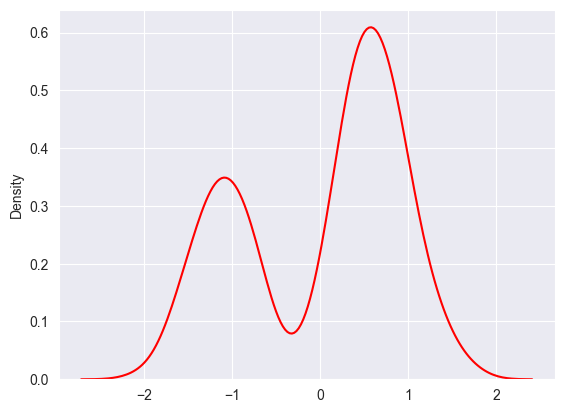

In [73]:
sns.kdeplot(simple_regression_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель без регуляризации")
plt.legend()

### Множественная регрессия с регуляризацией

Для начала с помощью кастомной функции получим модели с видами регуляризаций L1, L2, ElasticNet. В дальнейшем рассмотрим каждый вид регуляризации отдельно.

In [22]:
models_with_regularization = train_models_with_reg(X_train, y_train, X_val_test, y_val_test)

#### L1 регуляризация

In [23]:
l1_models = models_with_regularization["L1"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l1_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 0.0032374575428176433}
Способ подбора параметров: RandomSearch
{'alpha': 0.021209508879201904}
Способ подбора параметров: Optuna
{'alpha': 0.004896296744967195}


Видим, что оптимальные параметры получились примерно одинаковыми с точностью до 5 знаков после запятой. Попробуем использовать модель с параметрами, вычисленными GridSearch.

In [24]:
l1_multiple_model = l1_models["GridSearch"]["model"]

l1_multiple_model.coef_

array([ 1.40992760e-01,  1.50440485e-01,  1.49937637e-01,  1.47841340e-01,
        4.43517257e-04, -8.03314209e-05, -0.00000000e+00, -0.00000000e+00,
        1.70579090e-01,  1.70952079e-01,  1.81582822e-01,  1.68725799e-01,
       -1.11646080e+00])

В результате применения Lasso-регуляризации значения весов уменьшились. Некоторые из весов обратились в ноль из-за наличия мультиколлинеарности.

In [25]:
l1_multiple_model_train_predict = l1_multiple_model.predict(X_train)
l1_multiple_model_test_predict = l1_multiple_model.predict(X_val_test)

input_metrics_into_the_table(
    "Linear regression with Lasso regularization",
    l1_multiple_model_train_predict, y_train,
    l1_multiple_model_test_predict, y_val_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                    \
                                                    R2   MSE  RMSE   MAE   
Linear regression without regularization         0.820 0.185 0.430 0.343   
Linear regression with Lasso regularization      0.820 0.185 0.430 0.344   

                                                  Test Data                    \
                                             MAPE        R2   MSE  RMSE   MAE   
Linear regression without regularization    1.970     0.810 0.185 0.431 0.343   
Linear regression with Lasso regularization 1.967     0.810 0.185 0.430 0.343   

                                                   
                                             MAPE  
Linear regression without regularization    3.029  
Linear regression with Lasso regularization 3.010

В результате применения L1-регуляризации показатели метрик практически не изменились.

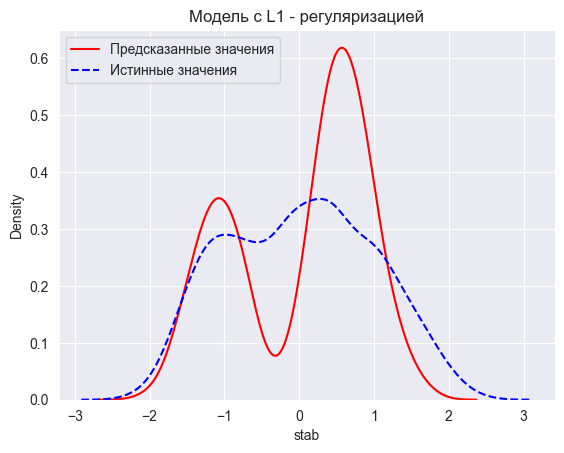

In [26]:
sns.kdeplot(l1_multiple_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_val_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель с L1 - регуляризацией")
plt.legend()

#### L2 регуляризация

In [27]:
l2_models = models_with_regularization["L2"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l2_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])

Способ подбора параметров: GridSearch
{'alpha': 0.001}
Способ подбора параметров: RandomSearch
{'alpha': 0.021209508879201904}
Способ подбора параметров: Optuna
{'alpha': 85.25890302685971}


Фреймворк Optuna показал в качестве результата наибольшее значение гиперпараметра. Попробуем применить эти результаты в модели.

In [28]:
l2_multiple_model = l2_models["Optuna"]["model"]

print(simple_model.coef_, l2_multiple_model.coef_, sep="\n")

[ 1.43677936e-01  1.53279556e-01  1.52705968e-01  1.50725576e-01
  1.83224341e-03 -2.66862035e-03 -1.31621955e-04 -3.82273622e-04
  1.73497526e-01  1.73622285e-01  1.84468149e-01  1.71695472e-01
 -1.11991569e+00]
[ 1.49965892e-01  1.59433401e-01  1.58928247e-01  1.57056903e-01
  1.75914535e-03 -2.34674321e-03  9.91408130e-05 -8.07945812e-04
  1.78262876e-01  1.79158269e-01  1.90036760e-01  1.76700358e-01
 -1.04991652e+00]


Заметим, что веса модели с L2 регуляризацией немного уменьшились в сравнении с весами модели без регуляризации.

In [29]:
l2_multiple_model_train_predict = l2_multiple_model.predict(X_train)
l2_multiple_model_test_predict = l2_multiple_model.predict(X_val_test)

input_metrics_into_the_table(
    "Linear regression with Ridge regularization",
    l2_multiple_model_train_predict, y_train,
    l2_multiple_model_test_predict, y_val_test,
    train_and_test_comparing
)
train_and_test_comparing

Train Data                    \
                                                    R2   MSE  RMSE   MAE   
Linear regression without regularization         0.820 0.185 0.430 0.343   
Linear regression with Lasso regularization      0.820 0.185 0.430 0.344   
Linear regression with Ridge regularization      0.820 0.185 0.431 0.344   

                                                  Test Data                    \
                                             MAPE        R2   MSE  RMSE   MAE   
Linear regression without regularization    1.970     0.810 0.185 0.431 0.343   
Linear regression with Lasso regularization 1.967     0.810 0.185 0.430 0.343   
Linear regression with Ridge regularization 1.879     0.810 0.185 0.430 0.341   

                                                   
                                             MAPE  
Linear regression without regularization    3.029  
Linear regression with Lasso regularization 3.010  
Linear regression with Ridge regularization 2.909

Модели с Lasso и Ridge регуляризациями в целом показывают одинаковые результаты. Их отличие лишь в метрике MAPE как для тестовых, так и для обучающих данных - в L2 регуляризации эта метрика уменьшилась.

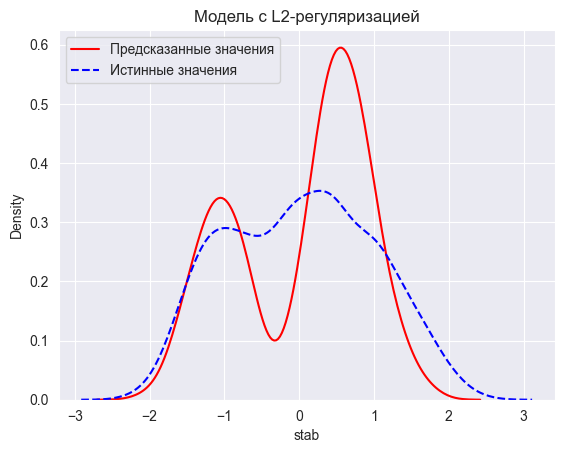

In [30]:
sns.kdeplot(l2_multiple_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_val_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель с L2-регуляризацией")
plt.legend()

#### Elastic Net регуляризация

In [31]:
elastic_net_multiple_models = models_with_regularization["EN"]

for name, model_dict in zip(names, elastic_net_multiple_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 0.004094915062380427, 'l1_ratio': 0.7000000000000001}
Способ подбора параметров: RandomSearch
{'l1_ratio': 0.1, 'alpha': 0.004094915062380427}
Способ подбора параметров: Optuna
{'alpha': 0.01145284572118822, 'l1_ratio': 0.3064394629514916}


Заметим, что Optuna и GridSearch показали примерно одинаковые результаты для параметров `alpha`. Попробуем получить предсказания с помощью полученных моделей и посмотрим на метрики.

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression without regularization                0.820 0.185 0.430   
Linear regression with Lasso regularization             0.820 0.185 0.430   
Linear regression with Ridge regularization             0.820 0.185 0.431   
Linear regression with Elastic Net (get with Gr...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Ra...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Op...      0.820 0.185 0.430   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Linear regression without regularization           0.343 1.970     0.810   
Linear regression with Lasso regularization        0.344 1.967     0.810   
Linear regression with Ridge regularization        0.344 1.879     0.810   
Linear regression with Elastic Net (get with Gr... 0.344 1.955     0.810   
Linear regression with Elastic Net (get with Ra... 0.343 1.935     0.810   
Linear regression with Elastic Net (get with Op... 0.344 1.895     0.810   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Linear regression without regularization           0.185 0.431 0.343 3.029  
Linear regression with Lasso regularization        0.185 0.430 0.343 3.010  
Linear regression with Ridge regularization        0.185 0.430 0.341 2.909  
Linear regression with Elastic Net (get with Gr... 0.185 0.430 0.342 2.997  
Linear regression with Elastic Net (get with Ra... 0.185 0.430 0.342 2.982  
Linear regression with Elastic Net (get with Op... 0.185 0.430 0.341 2.916

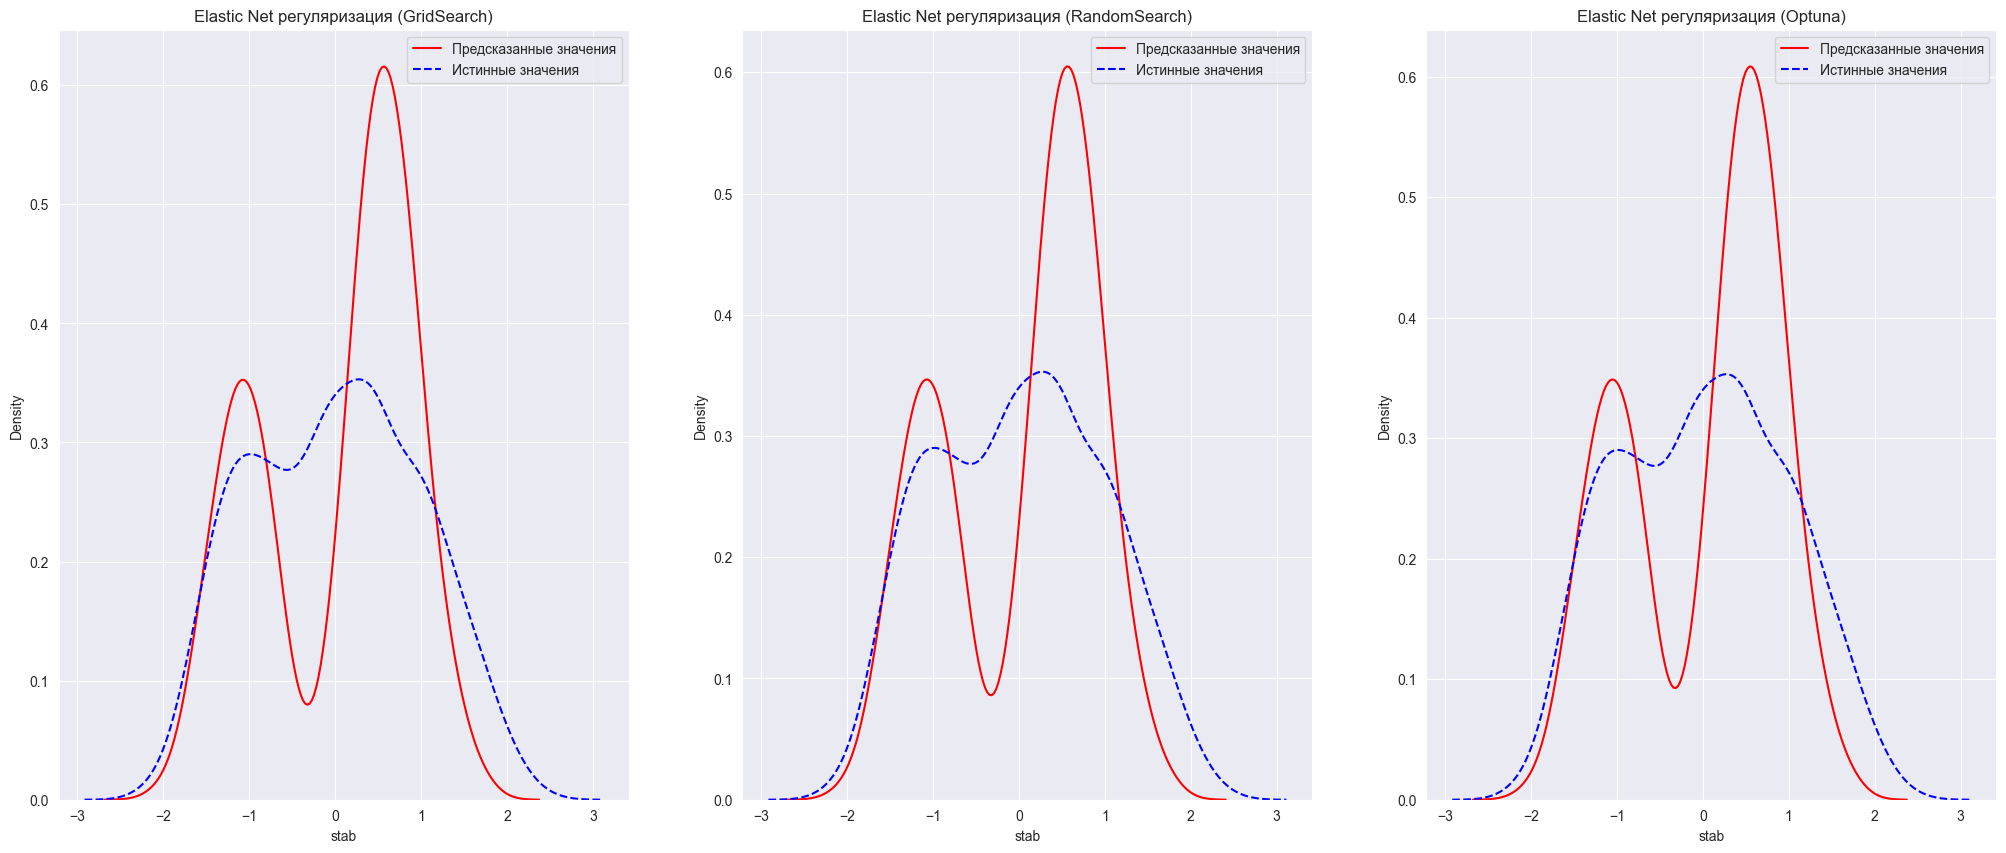

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = elastic_net_multiple_models[name]["model"]

    train_predict = model.predict(X_train)
    test_predict = model.predict(X_val_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="red")
    sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(f"Elastic Net регуляризация ({name})")
    ax.legend()

    input_metrics_into_the_table(
        f"Linear regression with Elastic Net (get with {name})",
        train_predict, y_train,
        test_predict, y_val_test,
        train_and_test_comparing
    )

train_and_test_comparing

Видим, что Elastic Net регуляризация с разными параметрами практически никак не повлияла на значения метрик

### Полиномиальная регрессия без регуляризации

Для начала используем модель с полиномом 2 степени.

#### Полиномиальная регрессия второй степени

In [33]:
poly = PolynomialFeatures(degree = 2)
X_poly2_train = poly.fit_transform(X_train)
X_poly2_test = poly.transform(X_val_test)

X_poly2_train.shape

(8000, 105)

In [34]:
model = LinearRegression()
model.fit(X_poly2_train, y_train)

train_predict = model.predict(X_poly2_train)
test_predict = model.predict(X_poly2_test)

input_metrics_into_the_table(
    f"Polynomial regression (deg 2) without regularization",
    train_predict, y_train,
    test_predict, y_val_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression without regularization                0.820 0.185 0.430   
Linear regression with Lasso regularization             0.820 0.185 0.430   
Linear regression with Ridge regularization             0.820 0.185 0.431   
Linear regression with Elastic Net (get with Gr...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Ra...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Op...      0.820 0.185 0.430   
Polynomial regression (deg 2) without regulariz...      0.930 0.073 0.270   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Linear regression without regularization           0.343 1.970     0.810   
Linear regression with Lasso regularization        0.344 1.967     0.810   
Linear regression with Ridge regularization        0.344 1.879     0.810   
Linear regression with Elastic Net (get with Gr... 0.344 1.955     0.810   
Linear regression with Elastic Net (get with Ra... 0.343 1.935     0.810   
Linear regression with Elastic Net (get with Op... 0.344 1.895     0.810   
Polynomial regression (deg 2) without regulariz... 0.205 1.056     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Linear regression without regularization           0.185 0.431 0.343 3.029  
Linear regression with Lasso regularization        0.185 0.430 0.343 3.010  
Linear regression with Ridge regularization        0.185 0.430 0.341 2.909  
Linear regression with Elastic Net (get with Gr... 0.185 0.430 0.342 2.997  
Linear regression with Elastic Net (get with Ra... 0.185 0.430 0.342 2.982  
Linear regression with Elastic Net (get with Op... 0.185 0.430 0.341 2.916  
Polynomial regression (deg 2) without regulariz... 0.077 0.278 0.210 1.289

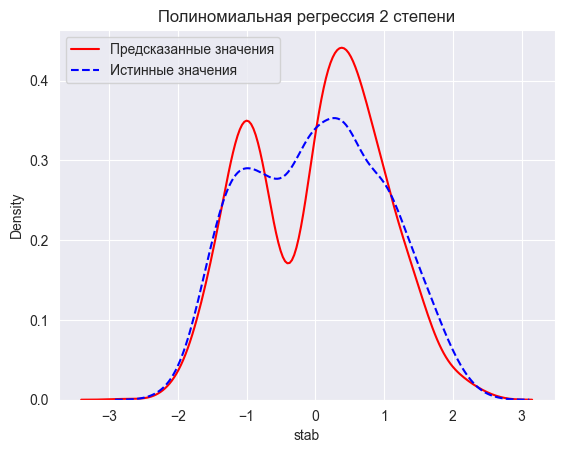

In [35]:
sns.kdeplot(test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_val_test, label="Истинные значения", color="blue", linestyle="--")
plt.title("Полиномиальная регрессия 2 степени")
plt.legend()

Видимо, что модель полиномиальной регрессии 2 степени показала лучшие результаты, чем предыдущие модели. Значения метрик улучшились: коэффициент R2 увеличился на тестовой и тренировочной выборках. Значения метрик MSE, RMSE, MAE, MAPE уменьшились.

На графике видно, что распределение предсказаний этой модели стало ближе к распределению истинных значений в сравнении с предыдущими моделями.


#### Полиномиальная регрессия 3 степени

In [36]:
poly3 = PolynomialFeatures(degree=3)

X_poly3_train = poly3.fit_transform(X_train)
X_poly3_test = poly3.transform(X_val_test)

X_poly3_train.shape

(8000, 560)

In [37]:
model = LinearRegression()
model.fit(X_poly3_train, y_train)

train_predict = model.predict(X_poly3_train)
test_predict = model.predict(X_poly3_test)

input_metrics_into_the_table(
    f"Polynomial regression (deg 3) without regularization",
    train_predict, y_train,
    test_predict, y_val_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression without regularization                0.820 0.185 0.430   
Linear regression with Lasso regularization             0.820 0.185 0.430   
Linear regression with Ridge regularization             0.820 0.185 0.431   
Linear regression with Elastic Net (get with Gr...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Ra...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Op...      0.820 0.185 0.430   
Polynomial regression (deg 2) without regulariz...      0.930 0.073 0.270   
Polynomial regression (deg 3) without regulariz...      0.970 0.034 0.184   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Linear regression without regularization           0.343 1.970     0.810   
Linear regression with Lasso regularization        0.344 1.967     0.810   
Linear regression with Ridge regularization        0.344 1.879     0.810   
Linear regression with Elastic Net (get with Gr... 0.344 1.955     0.810   
Linear regression with Elastic Net (get with Ra... 0.343 1.935     0.810   
Linear regression with Elastic Net (get with Op... 0.344 1.895     0.810   
Polynomial regression (deg 2) without regulariz... 0.205 1.056     0.920   
Polynomial regression (deg 3) without regulariz... 0.129 0.599     0.960   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Linear regression without regularization           0.185 0.431 0.343 3.029  
Linear regression with Lasso regularization        0.185 0.430 0.343 3.010  
Linear regression with Ridge regularization        0.185 0.430 0.341 2.909  
Linear regression with Elastic Net (get with Gr... 0.185 0.430 0.342 2.997  
Linear regression with Elastic Net (get with Ra... 0.185 0.430 0.342 2.982  
Linear regression with Elastic Net (get with Op... 0.185 0.430 0.341 2.916  
Polynomial regression (deg 2) without regulariz... 0.077 0.278 0.210 1.289  
Polynomial regression (deg 3) without regulariz... 0.039 0.197 0.138 0.631

Полином 3 степени дал лучшие значения метрик, чем полином 2 степени. Значение коэффициента R2 увеличилось, а значения прочих метрик уменьшились. Кроме того, значения метрик на тренировочной выборке лучше, чем значения метрик на тестовой выборке. Так, MAPE на тренировочной выборке равен 0.577, а на тестовой 0.652. Это говорит о том, что возможно переобучение модели.

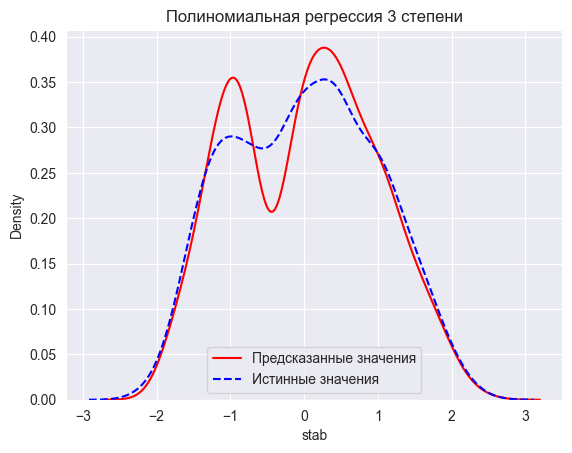

In [38]:
sns.kdeplot(test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_val_test, label="Истинные значения", color="blue", linestyle="--")
plt.title("Полиномиальная регрессия 3 степени")
plt.legend()

По графику распределения видно, что предсказанные значения стали ближе к истинным.

#### Полиномиальная регрессия 4 степени

In [39]:
poly4 = PolynomialFeatures(degree=4)

X_poly4_train = poly4.fit_transform(X_train)
X_poly4_test = poly4.transform(X_val_test)

X_poly4_train.shape

(8000, 2380)

In [40]:
model = LinearRegression()
model.fit(X_poly4_train, y_train)

train_predict = model.predict(X_poly4_train)
test_predict = model.predict(X_poly4_test)

input_metrics_into_the_table(
    f"Polynomial regression (deg 4) without regularization",
    train_predict, y_train,
    test_predict, y_val_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression without regularization                0.820 0.185 0.430   
Linear regression with Lasso regularization             0.820 0.185 0.430   
Linear regression with Ridge regularization             0.820 0.185 0.431   
Linear regression with Elastic Net (get with Gr...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Ra...      0.820 0.185 0.430   
Linear regression with Elastic Net (get with Op...      0.820 0.185 0.430   
Polynomial regression (deg 2) without regulariz...      0.930 0.073 0.270   
Polynomial regression (deg 3) without regulariz...      0.970 0.034 0.184   
Polynomial regression (deg 4) without regulariz...      0.980 0.019 0.136   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Linear regression without regularization           0.343 1.970     0.810   
Linear regression with Lasso regularization        0.344 1.967     0.810   
Linear regression with Ridge regularization        0.344 1.879     0.810   
Linear regression with Elastic Net (get with Gr... 0.344 1.955     0.810   
Linear regression with Elastic Net (get with Ra... 0.343 1.935     0.810   
Linear regression with Elastic Net (get with Op... 0.344 1.895     0.810   
Polynomial regression (deg 2) without regulariz... 0.205 1.056     0.920   
Polynomial regression (deg 3) without regulariz... 0.129 0.599     0.960   
Polynomial regression (deg 4) without regulariz... 0.093 0.356     0.970   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Linear regression without regularization           0.185 0.431 0.343 3.029  
Linear regression with Lasso regularization        0.185 0.430 0.343 3.010  
Linear regression with Ridge regularization        0.185 0.430 0.341 2.909  
Linear regression with Elastic Net (get with Gr... 0.185 0.430 0.342 2.997  
Linear regression with Elastic Net (get with Ra... 0.185 0.430 0.342 2.982  
Linear regression with Elastic Net (get with Op... 0.185 0.430 0.341 2.916  
Polynomial regression (deg 2) without regulariz... 0.077 0.278 0.210 1.289  
Polynomial regression (deg 3) without regulariz... 0.039 0.197 0.138 0.631  
Polynomial regression (deg 4) without regulariz... 0.032 0.180 0.121 0.508

Полином 4 степени дал лучшие метрики, чем полиномы 2 и 3 степени. 

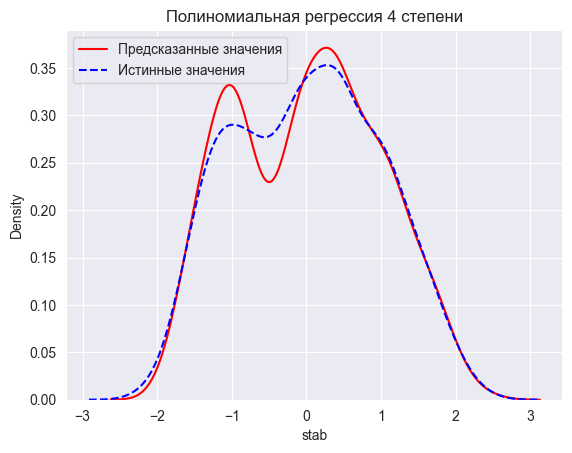

In [41]:
sns.kdeplot(test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_val_test, label="Истинные значения", color="blue", linestyle="--")
plt.title("Полиномиальная регрессия 4 степени")
plt.legend()

С увеличением степени полинома предсказанные значения стали еще ближе к истинным.

Попробуем использовать регуляризацию на полиномиальных моделях.

### Полиномиальная регрессия с регуляризацией

#### Полиномиальная регрессия 2 степени

In [42]:
models_with_regularization = train_models_with_reg(X_poly2_train, y_train, X_poly2_test, y_val_test)

##### L1 - регуляризация

In [43]:
l1_poly2_models = models_with_regularization["L1"]
l1_poly2_models

{'GridSearch': {'model': Lasso(alpha=0.001), 'best_params': {'alpha': 0.001}},
 'RandomSearch': {'model': Lasso(alpha=0.021209508879201904),
  'best_params': {'alpha': 0.021209508879201904}},
 'Optuna': {'model': Lasso(alpha=0.0010010653607205708),
  'best_params': {'alpha': 0.0010010653607205708}}}

In [44]:
for name_of_method, model_info in l1_poly2_models.items():
    print(name_of_method)
    print(model_info["model"].coef_)

GridSearch
[ 0.00000000e+00  2.01198997e-01  2.09126610e-01  2.05946517e-01
  2.03973710e-01  0.00000000e+00  0.00000000e+00 -7.63492584e-05
 -1.88379465e-03  2.68134942e-01  2.65931105e-01  2.73144526e-01
  2.70575762e-01 -5.86925825e-01 -1.45205377e-01  5.45362543e-02
  4.95846847e-02  5.41218195e-02  3.00594963e-05 -0.00000000e+00
 -3.17070688e-03  0.00000000e+00  1.03474656e-01 -7.89992520e-03
 -1.73989805e-02 -1.91815196e-02  2.14241749e-02 -1.43968150e-01
  4.92694118e-02  4.82911119e-02 -0.00000000e+00  7.44754934e-06
 -5.20258461e-04  2.71688547e-03 -2.17052148e-02  1.01771572e-01
 -1.68475958e-02 -1.93477142e-02  1.54582364e-02 -1.52231068e-01
  5.18695243e-02 -1.30685399e-04  0.00000000e+00  4.95037351e-03
  0.00000000e+00 -1.87628785e-02 -1.73447577e-02  1.05013723e-01
 -1.79079418e-02  2.01902785e-02 -1.44504700e-01  0.00000000e+00
 -0.00000000e+00  4.52902408e-03 -2.46839136e-03 -1.53354223e-02
 -1.64015163e-02 -1.46455493e-02  1.09588445e-01  1.85265596e-02
  7.67069056e-

После применения L1-регуляризации во всех моделях значения некоторых весов обратились в ноль.

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.271   
Polynomial regression(deg 2) with L1 (get with ...      0.910 0.092 0.304   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.271   
Polynomial regression (deg 2) without regulariz...      0.930 0.073 0.270   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression(deg 2) with L1 (get with ... 0.206 1.046     0.920   
Polynomial regression(deg 2) with L1 (get with ... 0.240 1.190     0.900   
Polynomial regression(deg 2) with L1 (get with ... 0.206 1.046     0.920   
Polynomial regression (deg 2) without regulariz... 0.205 1.056     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Polynomial regression(deg 2) with L1 (get with ... 0.077 0.279 0.211 1.294  
Polynomial regression(deg 2) with L1 (get with ... 0.094 0.307 0.239 1.615  
Polynomial regression(deg 2) with L1 (get with ... 0.077 0.279 0.211 1.294  
Polynomial regression (deg 2) without regulariz... 0.077 0.278 0.210 1.289

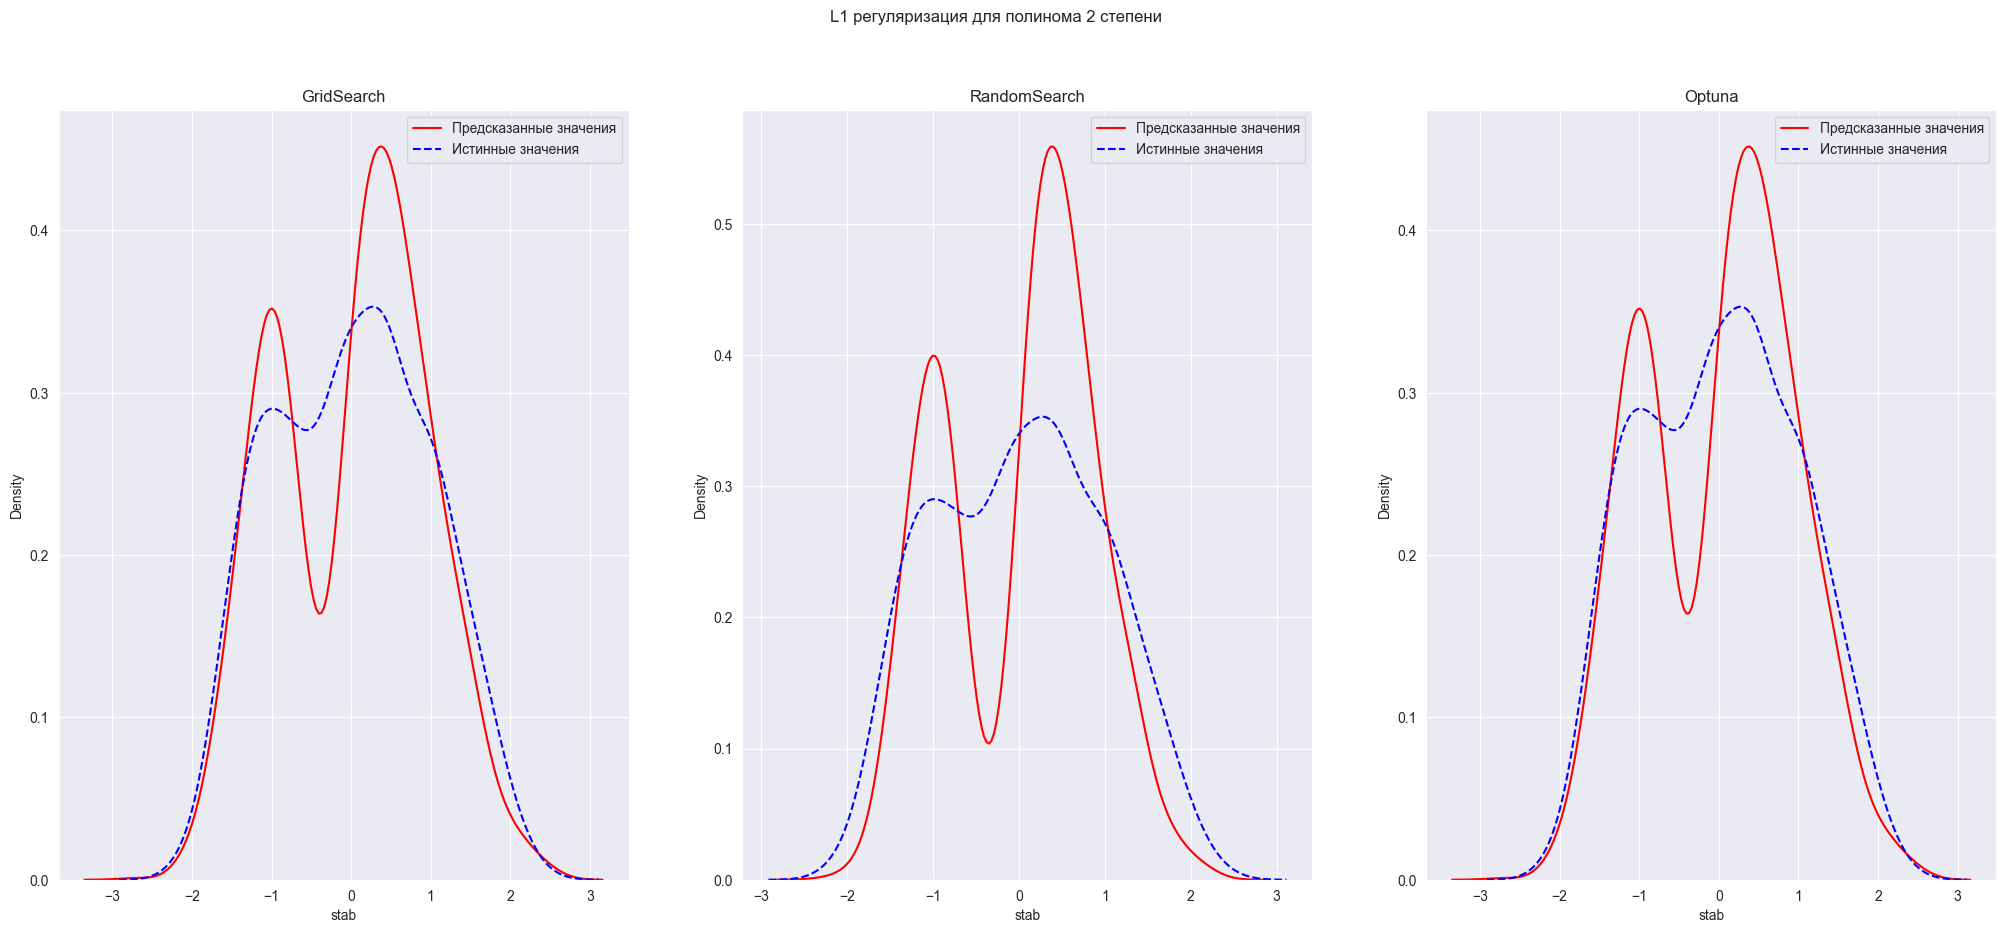

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = l1_poly2_models[name]["model"]

    train_predict = model.predict(X_poly2_train)
    test_predict = model.predict(X_poly2_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="red")
    sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(name)
    ax.legend()

    input_metrics_into_the_table(
        f"Polynomial regression(deg 2) with L1 (get with {name})",
        train_predict, y_train,
        test_predict, y_val_test,
        train_and_test_comparing
    )

plt.suptitle("L1 регуляризация для полинома 2 степени")

train_and_test_comparing.loc[["Polynomial regression(deg 2) with L1 (get with Optuna)",
                              "Polynomial regression(deg 2) with L1 (get with RandomSearch)",
                              "Polynomial regression(deg 2) with L1 (get with GridSearch)",
                              "Polynomial regression (deg 2) without regularization"]]

По графикам и метрикам видно, что наихудшее приближение к распределению истинных значений делает модель с гиперпараметрами, полученными RandomSearch.

Лучшие метрики показывают модели, обученные с помощью фреймворка Optuna и метода GridSearch. Значения метрик для моделей с регуляризацией и модели без регуляризации практически одни и те же.

##### L2-регуляризация

In [46]:
l2_poly2_models = models_with_regularization["L2"]
l2_poly2_models

{'GridSearch': {'model': Ridge(alpha=2.329951810515372, max_iter=1000),
  'best_params': {'alpha': 2.329951810515372}},
 'RandomSearch': {'model': Ridge(alpha=1.8420699693267164, max_iter=1000),
  'best_params': {'alpha': 1.8420699693267164}},
 'Optuna': {'model': Ridge(alpha=0.0010002779279308974),
  'best_params': {'alpha': 0.0010002779279308974}}}

In [47]:
for name_of_method, model_info in l2_poly2_models.items():
    print(name_of_method)
    print(model_info["model"].coef_)

GridSearch
[ 0.00000000e+00  2.04325285e-01  2.12359999e-01  2.09218145e-01
  2.07070921e-01  2.50956126e-04  1.45362137e-03 -1.65052124e-04
 -1.72446695e-03  2.78399958e-01  2.76633177e-01  2.83560280e-01
  2.80872071e-01 -2.94699075e-01 -1.46672216e-01  5.56246164e-02
  5.05765067e-02  5.55441083e-02  1.65768369e-03 -1.39273501e-04
 -3.37197705e-03  6.31937730e-04  1.03658952e-01 -1.14227539e-02
 -2.06580785e-02 -2.21260891e-02  1.95684124e-02 -1.45108910e-01
  4.99898449e-02  4.96141037e-02 -8.26563967e-04  6.35194594e-04
 -2.35785142e-03  3.15835783e-03 -2.50543708e-02  1.01383679e-01
 -2.00685329e-02 -2.24221197e-02  1.30599510e-02 -1.53981455e-01
  5.27336906e-02 -1.85385292e-03 -8.83499094e-04  4.87883745e-03
 -7.75290094e-04 -2.18805608e-02 -2.06700122e-02  1.04862423e-01
 -2.11048103e-02  1.75005403e-02 -1.45561532e-01 -2.37157562e-04
 -5.70163978e-04  5.09844394e-03 -4.11635054e-03 -1.82775294e-02
 -1.95223493e-02 -1.77691617e-02  1.10068338e-01  1.70435914e-02
  1.66289064e-

После применения L2-регуляризации для всех моделей значения большинства весов уменьшились.

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.073 0.270   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.073 0.270   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.073 0.270   
Polynomial regression (deg 2) without regulariz...      0.930 0.073 0.270   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression (deg 2) with L2 (get with... 0.205 1.056     0.920   
Polynomial regression (deg 2) with L2 (get with... 0.205 1.055     0.920   
Polynomial regression (deg 2) with L2 (get with... 0.205 1.055     0.920   
Polynomial regression (deg 2) without regulariz... 0.205 1.056     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Polynomial regression (deg 2) with L2 (get with... 0.077 0.278 0.210 1.289  
Polynomial regression (deg 2) with L2 (get with... 0.077 0.278 0.210 1.289  
Polynomial regression (deg 2) with L2 (get with... 0.077 0.278 0.210 1.289  
Polynomial regression (deg 2) without regulariz... 0.077 0.278 0.210 1.289

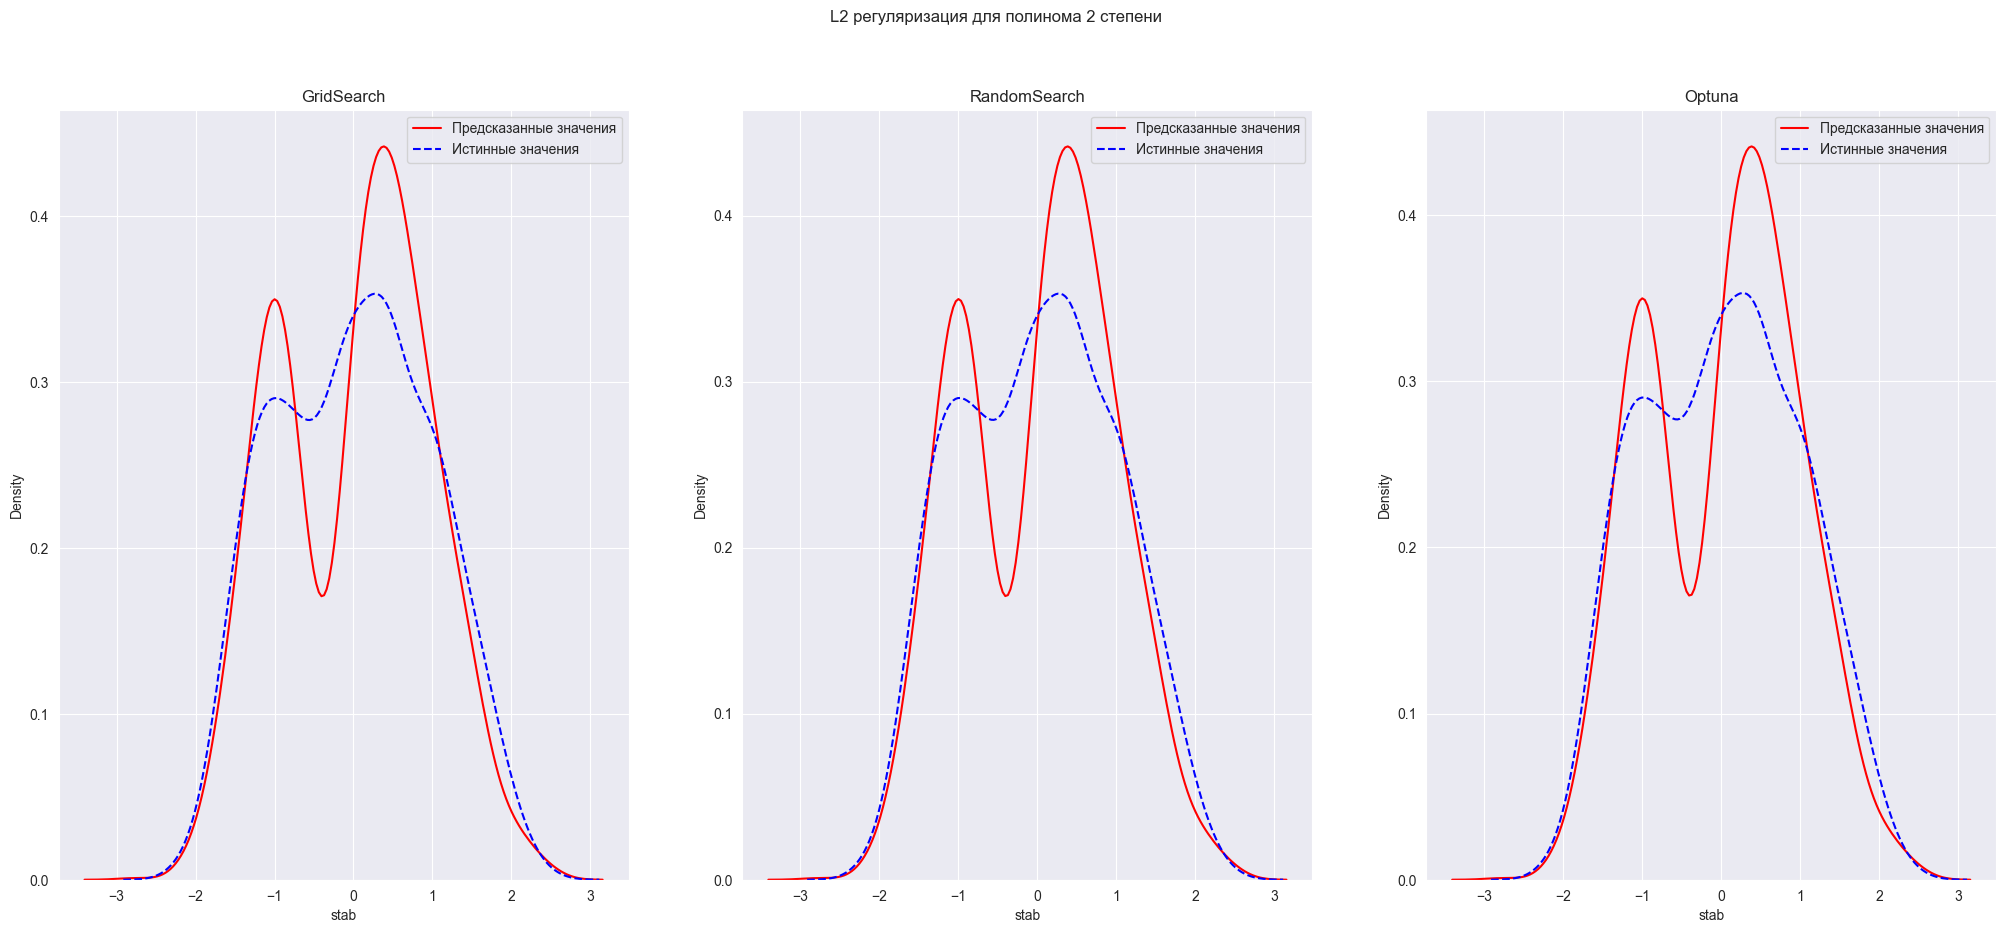

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = l2_poly2_models[name]["model"]

    train_predict = model.predict(X_poly2_train)
    test_predict = model.predict(X_poly2_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="red")
    sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(name)
    ax.legend()

    input_metrics_into_the_table(
        f"Polynomial regression (deg 2) with L2 (get with {name})",
        train_predict, y_train,
        test_predict, y_val_test,
        train_and_test_comparing
    )

plt.suptitle("L2 регуляризация для полинома 2 степени")

train_and_test_comparing.loc[["Polynomial regression (deg 2) with L2 (get with Optuna)",
                              "Polynomial regression (deg 2) with L2 (get with RandomSearch)",
                              "Polynomial regression (deg 2) with L2 (get with GridSearch)",
                              "Polynomial regression (deg 2) without regularization"]]

Для всех полученных гиперпараметров L2 регуляризация дала значения практически одинаковых метрик.

Стоит отметить, что применение L2 регуляризации практически никак не повлияло на значения метрик в сравнении с моделью без регуляризации.

##### Elastic-Net регуляризация

In [49]:
en_poly2_models = models_with_regularization["EN"]
en_poly2_models

{'GridSearch': {'model': ElasticNet(alpha=0.001, l1_ratio=0.7000000000000001),
  'best_params': {'alpha': 0.001, 'l1_ratio': 0.7000000000000001}},
 'RandomSearch': {'model': ElasticNet(alpha=0.004094915062380427, l1_ratio=0.1),
  'best_params': {'l1_ratio': 0.1, 'alpha': 0.004094915062380427}},
 'Optuna': {'model': ElasticNet(alpha=0.001002854558825648, l1_ratio=0.11087501865196882),
  'best_params': {'alpha': 0.001002854558825648,
   'l1_ratio': 0.11087501865196882}}}

In [50]:
for name_of_method, model_info in en_poly2_models.items():
    print(name_of_method)
    print(model_info["model"].coef_)

GridSearch
[ 0.00000000e+00  2.01923972e-01  2.09883634e-01  2.06681523e-01
  2.04690167e-01  0.00000000e+00  0.00000000e+00 -2.44025335e-04
 -1.90198824e-03  2.70847204e-01  2.68692723e-01  2.75922986e-01
  2.73276524e-01 -3.20285275e-01 -1.45574752e-01  5.49276957e-02
  4.99671640e-02  5.45943638e-02  2.36157527e-04 -1.15719611e-04
 -3.34912860e-03  0.00000000e+00  1.03588101e-01 -8.83127949e-03
 -1.82699807e-02 -1.99693173e-02  2.13763829e-02 -1.44274762e-01
  4.95509608e-02  4.87545511e-02 -0.00000000e+00  4.01271643e-04
 -8.91434729e-04  2.99189437e-03 -2.26050248e-02  1.01765519e-01
 -1.77194210e-02 -2.01805403e-02  1.52760540e-02 -1.52703377e-01
  5.22048534e-02 -2.67937053e-04  0.00000000e+00  5.16903063e-03
  0.00000000e+00 -1.95756298e-02 -1.82258995e-02  1.05038416e-01
 -1.87642814e-02  1.99192295e-02 -1.44773409e-01  0.00000000e+00
 -0.00000000e+00  4.77799170e-03 -2.90242386e-03 -1.61261531e-02
 -1.72176195e-02 -1.54864649e-02  1.09783401e-01  1.85707505e-02
  4.54391254e-

При применении Elastic Net регуляризации значения большинства весов уменьшились, некоторые обратились в ноль.

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.271   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.271   
Polynomial regression (deg 2) without regulariz...      0.930 0.073 0.270   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression (deg 2) with Elastic Net ... 0.205 1.052     0.920   
Polynomial regression (deg 2) with Elastic Net ... 0.205 1.047     0.920   
Polynomial regression (deg 2) with Elastic Net ... 0.205 1.047     0.920   
Polynomial regression (deg 2) without regulariz... 0.205 1.056     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Polynomial regression (deg 2) with Elastic Net ... 0.077 0.278 0.210 1.288  
Polynomial regression (deg 2) with Elastic Net ... 0.077 0.279 0.211 1.286  
Polynomial regression (deg 2) with Elastic Net ... 0.077 0.278 0.211 1.292  
Polynomial regression (deg 2) without regulariz... 0.077 0.278 0.210 1.289

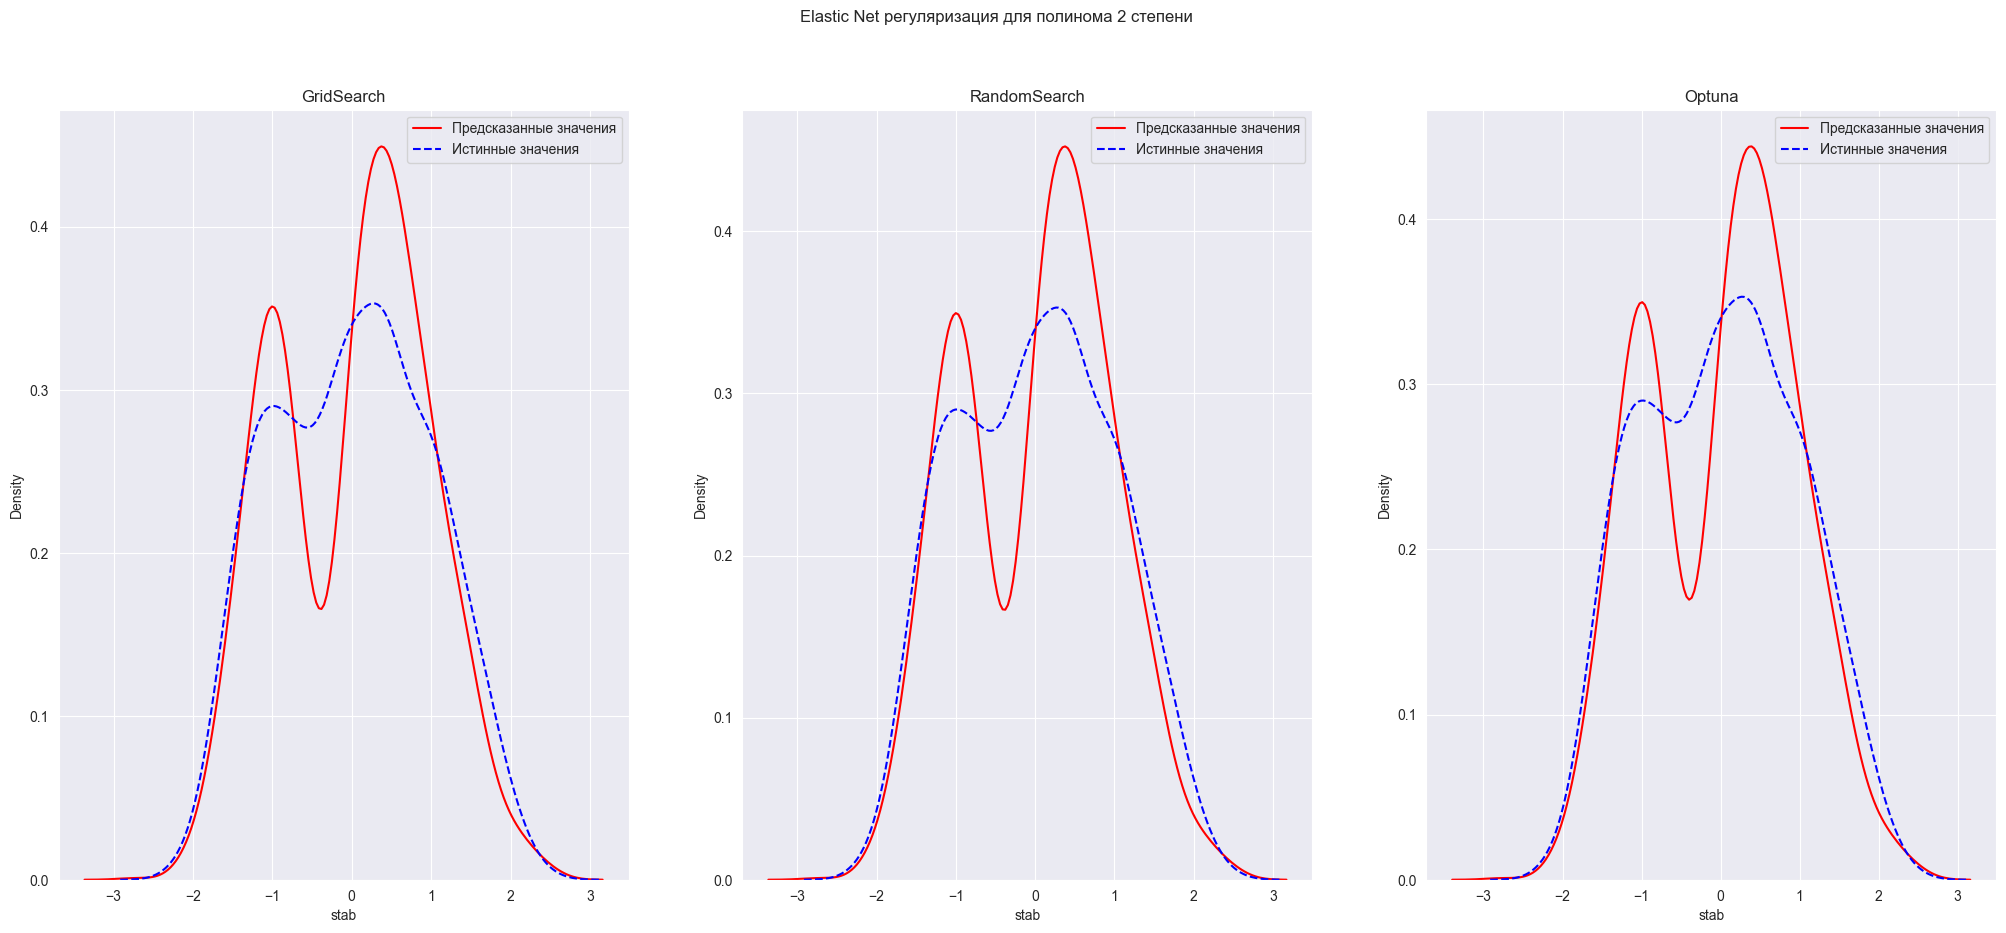

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = en_poly2_models[name]["model"]

    train_predict = model.predict(X_poly2_train)
    test_predict = model.predict(X_poly2_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="r")
    sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(name)
    ax.legend()

    input_metrics_into_the_table(
        f"Polynomial regression (deg 2) with Elastic Net (get with {name})",
        train_predict, y_train,
        test_predict, y_val_test,
        train_and_test_comparing
    )

plt.suptitle("Elastic Net регуляризация для полинома 2 степени")

train_and_test_comparing.loc[["Polynomial regression (deg 2) with Elastic Net (get with Optuna)",
                              "Polynomial regression (deg 2) with Elastic Net (get with RandomSearch)",
                              "Polynomial regression (deg 2) with Elastic Net (get with GridSearch)",
                              "Polynomial regression (deg 2) without regularization"]]

Применение Elastic Net регуляризации никак не повлияло на показатели метрик в сравнении с моделью без регуляризации.

#### Полиномиальная регрессия 3 и 4 степени

KeyboardInterrupt: 

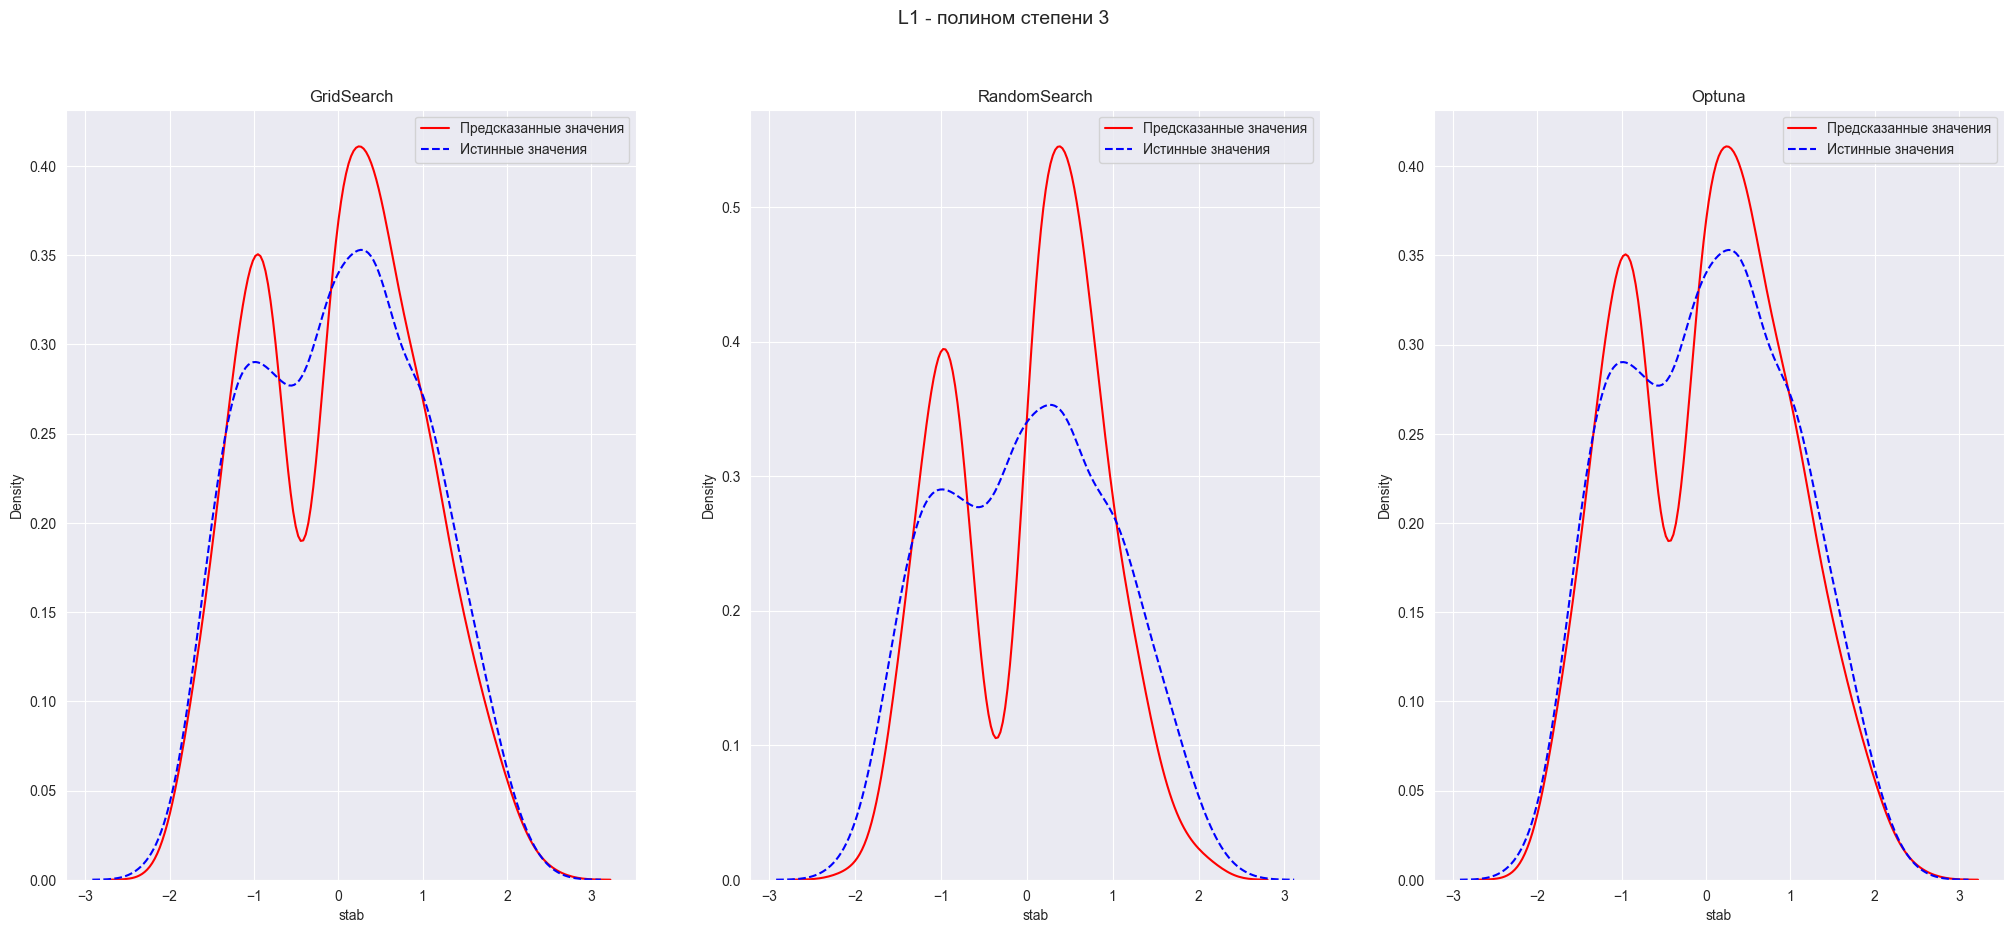

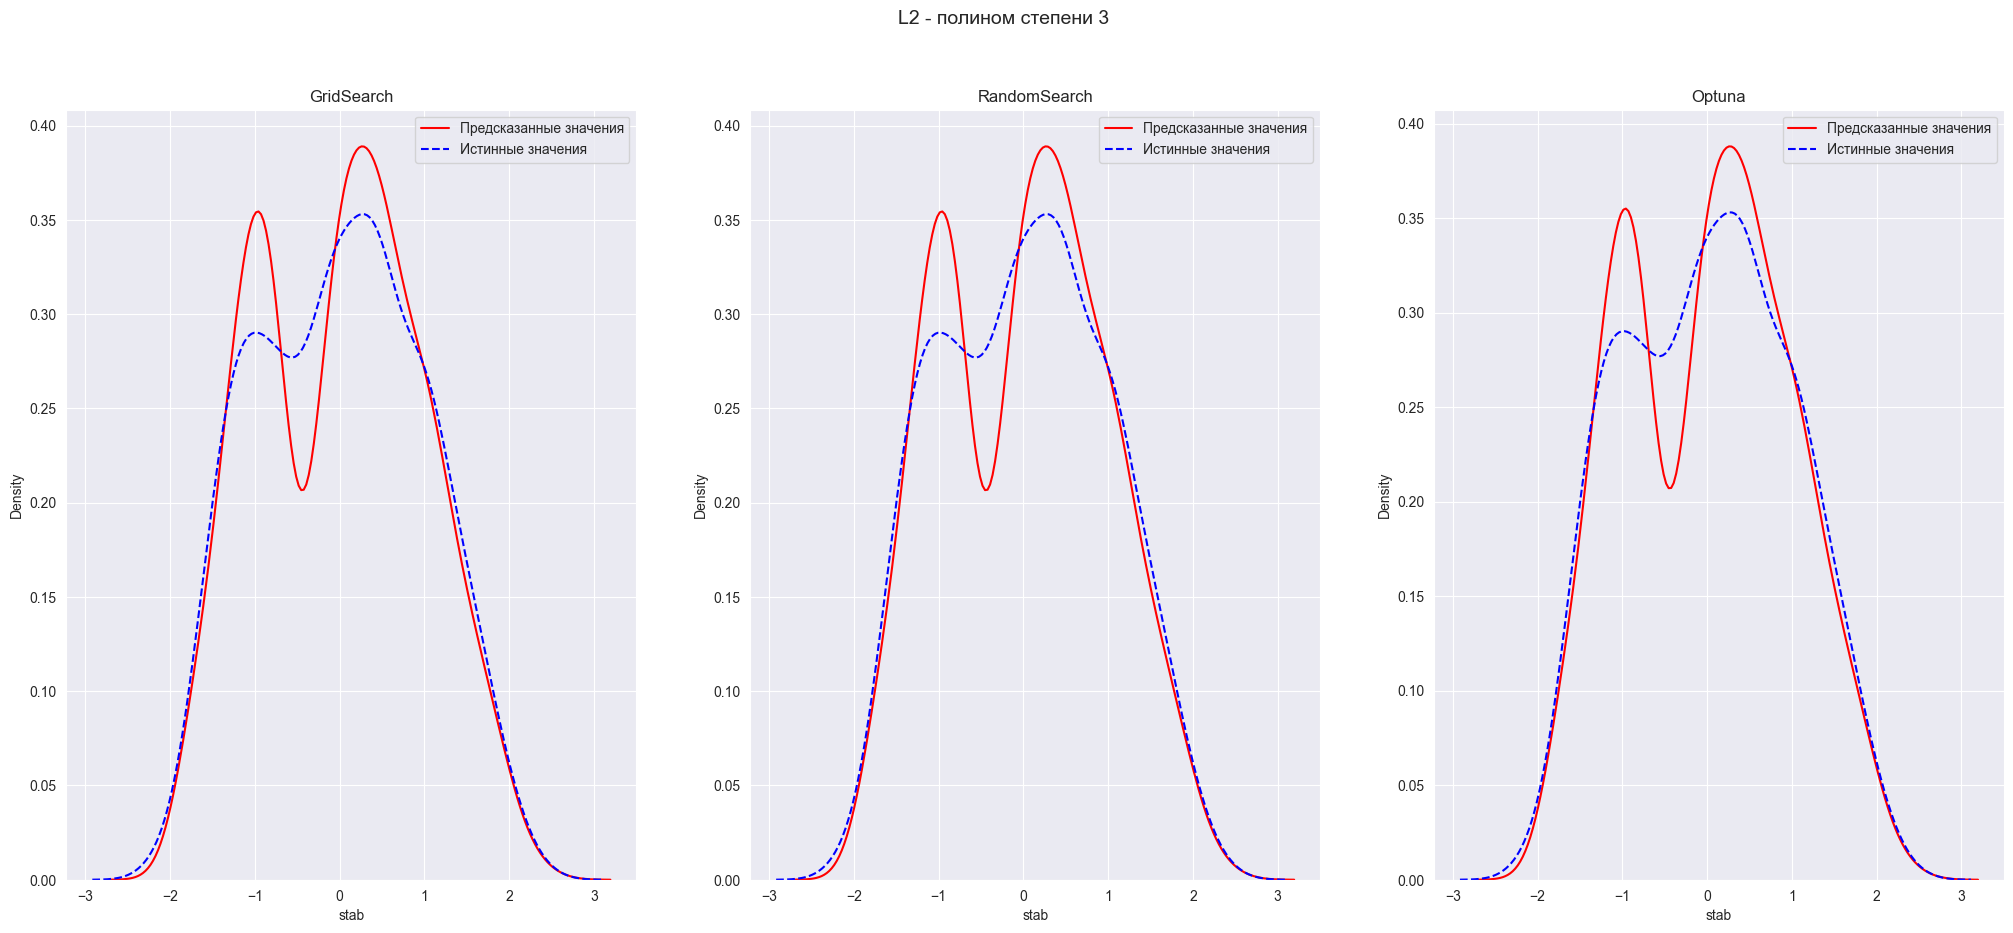

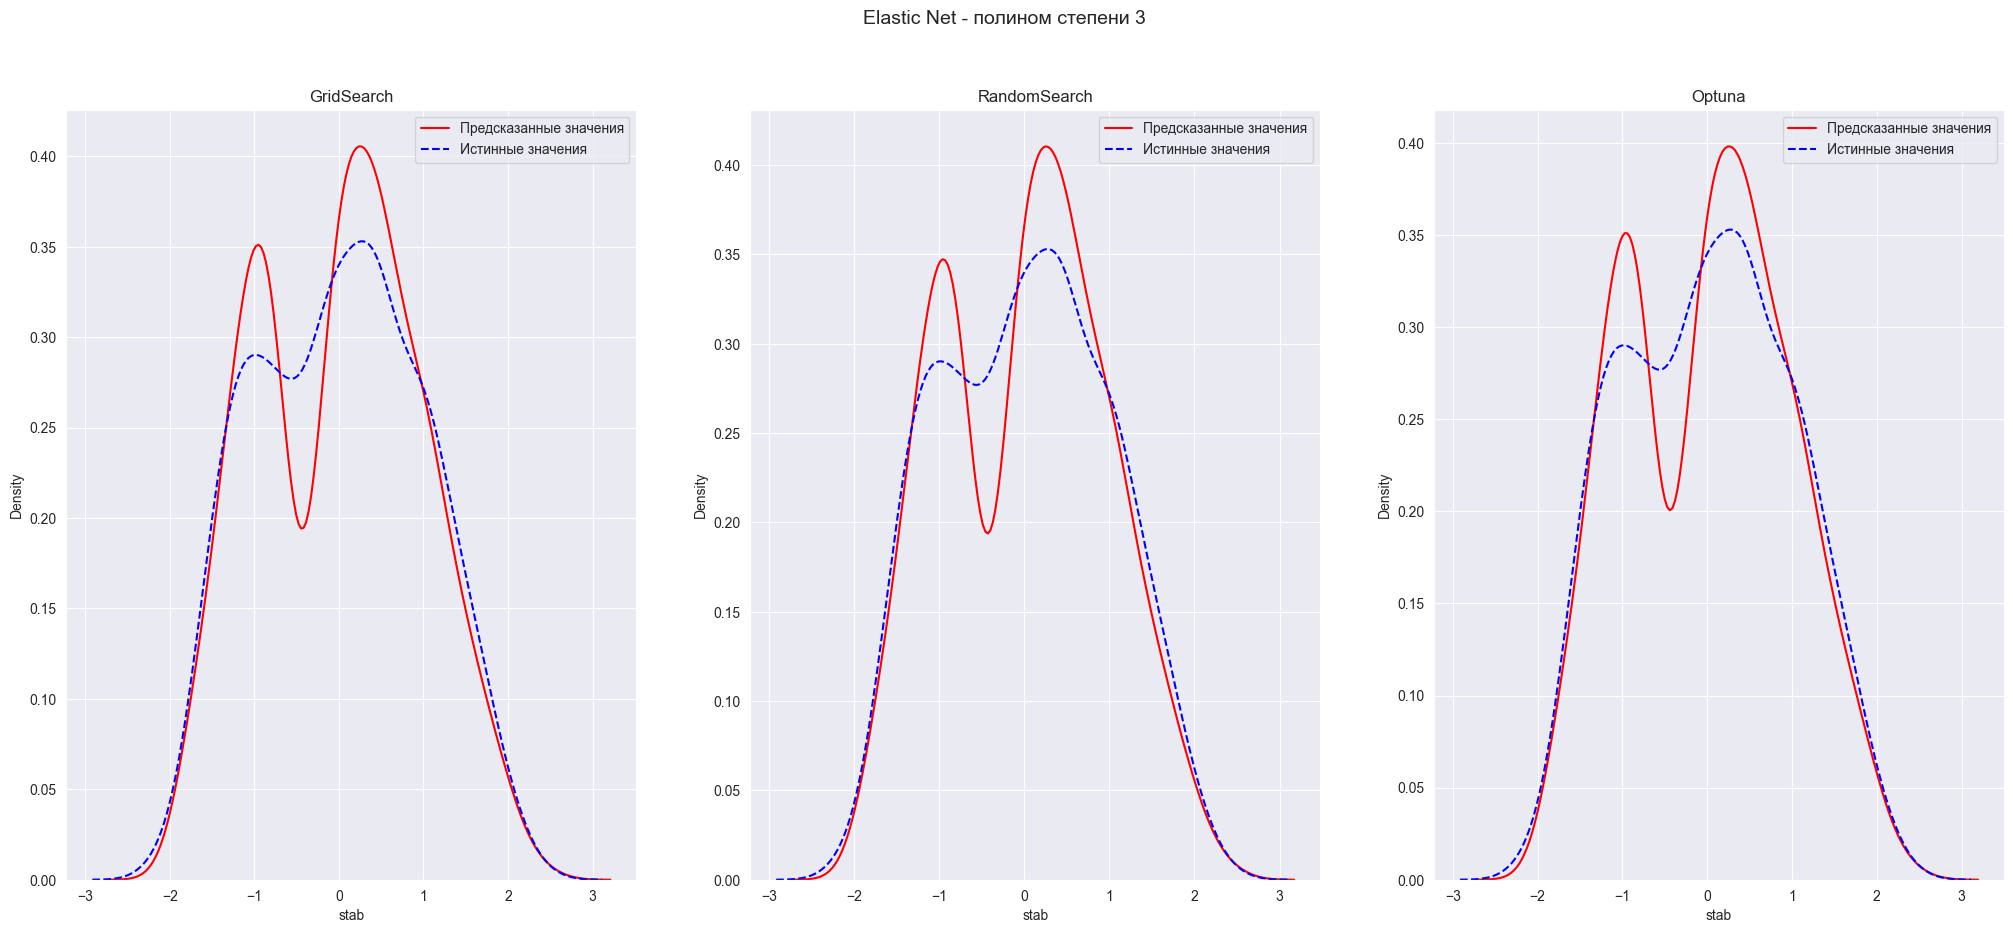

In [52]:
polynomial_X = [(X_poly3_train, X_poly3_test), (X_poly4_train, X_poly4_test)]
results = {}
for i, (X_poly_train, X_poly_test) in enumerate(polynomial_X, start=3):
    degree = i

    models_with_regularization = train_models_with_reg(
        X_poly_train, y_train,
        X_poly_test, y_val_test
    )

    results[degree] = models_with_regularization

    l1_models = models_with_regularization["L1"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"L1 - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):

        model = l1_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", color="red")
        sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with L1 ({name})"
        input_metrics_into_the_table(
            key, train_pred, y_train, test_pred, y_val_test, train_and_test_comparing
        )



    l2_models = models_with_regularization["L2"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"L2 - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):
        model = l2_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", color="red")
        sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with L2 ({name})"
        input_metrics_into_the_table(
            key, train_pred, y_train, test_pred, y_val_test, train_and_test_comparing
        )



    en_models = models_with_regularization["EN"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"Elastic Net - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):
        model = en_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", color="red")
        sns.kdeplot(y_val_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with Elastic Net ({name})"
        input_metrics_into_the_table(
            key, train_pred, y_train, test_pred, y_val_test, train_and_test_comparing
        )



По графикам видно, что модель полиномиальной регрессии 4 степени работает лучшим образом. Посмотрим на значения метрик в общей таблице.

## Вывод

### Выбор лучшей модели

In [61]:
train_and_test_comparing.sort_values(by=("Test Data", "R2"), ascending=False)

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 4) with L2 (Optuna)          0.980 0.018 0.134   
Polynomial regression (deg 4) with L1 (Optuna)          0.980 0.023 0.152   
Polynomial regression (deg 4) with L2 (GridSearch)      0.980 0.018 0.135   
Polynomial regression (deg 4) without regulariz...      0.980 0.018 0.134   
Polynomial regression (deg 4) with Elastic Net ...      0.980 0.021 0.144   
Polynomial regression (deg 4) with Elastic Net ...      0.980 0.021 0.145   
Polynomial regression (deg 4) with Elastic Net ...      0.980 0.022 0.150   
Polynomial regression (deg 4) with L1 (GridSearch)      0.980 0.023 0.152   
Polynomial regression (deg 4) with L2 (RandomSe...      0.980 0.018 0.135   
Polynomial regression (deg 3) with L2 (RandomSe...      0.970 0.034 0.183   
Polynomial regression (deg 3) with L1 (GridSearch)      0.970 0.035 0.187   
Polynomial regression (deg 3) with L2 (GridSearch)      0.970 0.034 0.183   
Polynomial regression (deg 3) with L1 (Optuna)          0.970 0.035 0.187   
Polynomial regression (deg 3) without regulariz...      0.970 0.034 0.183   
Polynomial regression (deg 3) with Elastic Net ...      0.970 0.035 0.186   
Polynomial regression (deg 3) with Elastic Net ...      0.970 0.034 0.184   
Polynomial regression (deg 3) with L2 (Optuna)          0.970 0.034 0.183   
Polynomial regression (deg 3) with Elastic Net ...      0.970 0.034 0.185   
Polynomial regression (deg 2) without regulariz...      0.930 0.072 0.269   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.270   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.072 0.269   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 3) with L1 (RandomSe...      0.920 0.081 0.285   
Polynomial regression (deg 4) with L1 (RandomSe...      0.910 0.090 0.300   
Polynomial regression(deg 2) with L1 (get with ...      0.910 0.092 0.303   
Linear regression with Lasso regularization             0.820 0.184 0.429   
Linear regression without regularization                0.820 0.184 0.429   
Linear regression with Elastic Net (get with Gr...      0.820 0.184 0.429   
Linear regression with Ridge regularization             0.820 0.184 0.429   
Linear regression with Elastic Net (get with Ra...      0.820 0.184 0.429   
Linear regression with Elastic Net (get with Op...      0.820 0.184 0.429   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression (deg 4) with L2 (Optuna)     0.092 0.341     0.970   
Polynomial regression (deg 4) with L1 (Optuna)     0.104 0.386     0.970   
Polynomial regression (deg 4) with L2 (GridSearch) 0.092 0.338     0.970   
Polynomial regression (deg 4) without regulariz... 0.092 0.342     0.970   
Polynomial regression (deg 4) with Elastic Net ... 0.099 0.367     0.970   
Polynomial regression (deg 4) with Elastic Net ... 0.098 0.368     0.970   
Polynomial regression (deg 4) with Elastic Net ... 0.102 0.380     0.970   
Polynomial regression (deg 4) with L1 (GridSearch) 0.104 0.386     0.970   
Polynomial regression (deg 4) with L2 (RandomSe... 0.093 0.337     0.960   
Polynomial regression (deg 3) with L2 (RandomSe... 0.128 0.578     0.960   
Polynomial regression (deg 3) with L1 (GridSearch) 0.131 0.581     0.960   
Polynomial regression (deg 3) with L2 (GridSearch) 0.128 0.578     0.960   
Polynomial regression (deg 3) with L1 (Optuna)     0.131 0.5

Наилучшей обученной моделью оказалась модель полиномиальной регрессии 4 степени с регуляризацией L1 (Optuna). Эта модель обладает лучшими метриками среди обученных моделей:
* R2: 0.970
* RMSE: 0.182
* MSE: 0.033,
* MAPE: 0.588,
* MAE: 0.122

В целом лучше всего на данных себя проявили модели полиномиальной регрессии. Причем с увеличением степени полинома модель давала предсказания, более близкие к истинным.


### Восстановление уравнения регрессии для лучшей модели

In [139]:
best_model = results[4]["L1"]["Optuna"]["model"]

b0 = best_model.intercept_
coefs = model.coef_

features = poly4.get_feature_names_out()


regression_eq = [f"{b0:.6f}"]

for feature, coef in zip(features, coefs):
    if coef != 0:
        sign = " + " if coef >=0 else " - "
        coef = abs(coef)
        regression_eq.append(f"{sign}{coef:.6f} * {feature}")

equation = "".join(regression_eq)
equation

'1.016035 + 0.203456 * tau1 + 0.211639 * tau2 + 0.207699 * tau3 + 0.206126 * tau4 + 0.000258 * p2 - 0.000749 * p3 - 0.000192 * p4 + 0.276000 * g1 + 0.273114 * g2 + 0.282428 * g3 + 0.278931 * g4 - 0.297357 * stabf - 0.145052 * tau1^2 + 0.054677 * tau1 tau2 + 0.051399 * tau1 tau3 + 0.055610 * tau1 tau4 + 0.001693 * tau1 p1 - 0.001233 * tau1 p3 + 0.103723 * tau1 g1 - 0.009689 * tau1 g2 - 0.020819 * tau1 g3 - 0.021263 * tau1 g4 + 0.022578 * tau1 stabf - 0.145223 * tau2^2 + 0.049583 * tau2 tau3 + 0.048993 * tau2 tau4 + 0.002267 * tau2 p2 - 0.004233 * tau2 p3 + 0.002883 * tau2 p4 - 0.024064 * tau2 g1 + 0.102894 * tau2 g2 - 0.018750 * tau2 g3 - 0.020828 * tau2 g4 + 0.016093 * tau2 stabf - 0.154430 * tau3^2 + 0.051911 * tau3 tau4 - 0.001126 * tau3 p1 + 0.006328 * tau3 p3 - 0.020800 * tau3 g1 - 0.021892 * tau3 g2 + 0.102973 * tau3 g3 - 0.020885 * tau3 g4 + 0.019239 * tau3 stabf - 0.145653 * tau4^2 - 0.000984 * tau4 p2 + 0.005933 * tau4 p3 - 0.003910 * tau4 p4 - 0.020792 * tau4 g1 - 0.020083 * t

# Практическая работа № 4

In [ ]:
def input_in_train_val_table(name_of_model, pred_train, y_train, pred_val, y_val, table):
    val_metrics = get_metrics(y_val, pred_val)
    train_metrics = get_metrics(y_train, pred_train)

    table.loc[name_of_model] = train_metrics + val_metrics

def input_in_test_table(name_of_model, y_test, pred_test, table):
    test_metrics = get_metrics(y_test, pred_test)

    table.loc[name_of_model] = test_metrics

In [ ]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Val Data"],
    metrics
])

train_and_val_metrics_comparing = pd.DataFrame(columns=columns)

train_and_val_metrics_comparing

Разделим данные на тренировочные, валидационные и тестовые в пропорциональности 80 - 10 - 10

In [ ]:
columns = pd.MultiIndex.from_product([
    ["Test Data"],
    metrics
])

test_metrics = pd.DataFrame(columns=columns)

test_metrics

In [ ]:
X_val, X_val_test, y_val, y_val_test = train_test_split(X_val_test, y_val_test, test_size=0.5)

models = []

### Множественная регрессия без регуляризации

In [ ]:
simple_regression_model = LinearRegression()
simple_regression_model.fit(X_train, y_train)

simple_regression_model.coef_

In [ ]:
simple_regression_model_train_predict = simple_regression_model.predict(X_train)
simple_regression_model_val_predict = simple_regression_model.predict(X_val_test)

input_in_train_val_table(
    "Linear regression without regularization",
    simple_regression_model_train_predict, y_train,
    simple_regression_model_val_predict, y_val_test,
    train_and_val_metrics_comparing
)

train_and_val_metrics_comparing.loc["Linear regression without regularization"]

In [ ]:
sns.regplot(x = simple_regression_model_val_predict, y=y_val_test, line_kws={"color": "r"}, scatter_kws={"color": "b", "alpha": 0.3})

In [ ]:
sns.kdeplot(simple_regression_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_val_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель без регуляризации")
plt.legend()

### Множественная регрессия с регуляризацией

In [ ]:
models_with_regularization = train_models_with_reg(X_train, y_train, X_val_test, y_val_test)

In [ ]:
l1_models = models_with_regularization["L1"]